<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Bubble Plots**


Estimated time needed: **30** minutes


In this lab, you will focus on visualizing data.

The dataset will be directly loaded into pandas for analysis and visualization.

You will use various visualization techniques to explore the data and uncover key trends.


## Objectives


In this lab, you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two data features.

-   Visualize composition of data.

-   Visualize comparison of data.


#### Setup: Working with the Database
**Install and import the needed libraries**


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



In [3]:
# Load the data
df = pd.read_csv("/Users/michalbando/Downloads/Różne/IT/Python/data/survey_data.csv")

# Display the first few rows of the data to understand its structure
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Exploring Data Distributions Using Bubble Plots


#### 1. Bubble Plot for Age vs. Frequency of Participation


- Visualize the relationship between respondents’ age and their participation frequency (`SOPartFreq`) using a bubble plot.

- Use the size of the bubbles to represent their job satisfaction (`JobSat`).


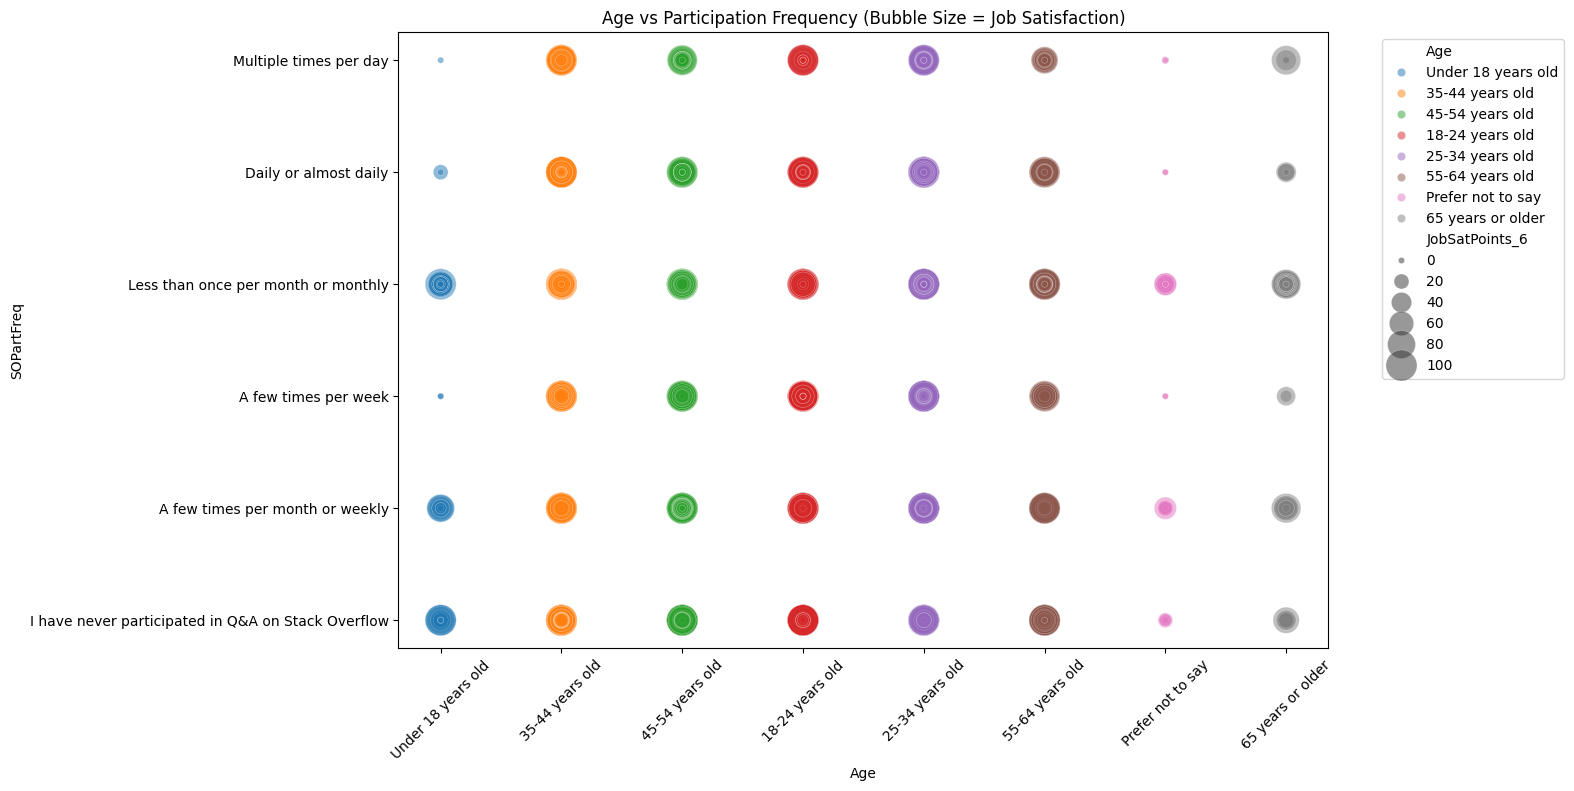

In [ ]:
# Mapujemy wiek i satysfakcję na liczby, by bąbelki miały sensowną wielkość
age_order = ['Under 18 years old', '18-24 years old', '25-34 years old', '35-44 years old', '45-54 years old', '55-64 years old', '65 years or older']
df['AgeNumeric'] = df['Age'].map({v: i+1 for i, v in enumerate(age_order)})

plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='Age', y='SOPartFreq', size='JobSatPoints_6', hue='Age',
                alpha=0.5, sizes=(20, 500))
plt.title('Age vs Participation Frequency (Bubble Size = Job Satisfaction)')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

#### 2. Bubble Plot for Compensation vs. Job Satisfaction


-Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSat`).

- Use the size of the bubbles to represent respondents’ age.


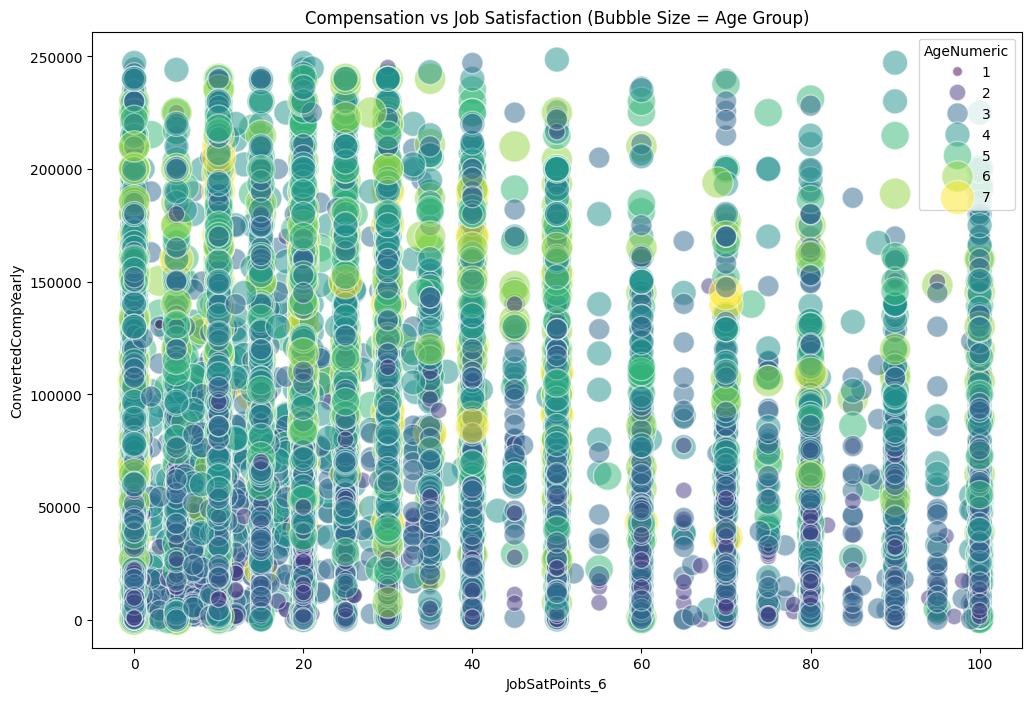

In [ ]:
# Usuwamy outliery dla czytelności (pensje < 250k)
df_clean = df[df['ConvertedCompYearly'] < 250000].copy()

plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_clean, x='JobSatPoints_6', y='ConvertedCompYearly',
                size='AgeNumeric', hue='AgeNumeric', alpha=0.5, sizes=(50, 600), palette='viridis')
plt.title('Compensation vs Job Satisfaction (Bubble Size = Age Group)')
plt.show()

### Task 2: Analyzing Relationships Using Bubble Plots


#### 1. Bubble Plot of Technology Preferences by Age

- Visualize the popularity of programming languages respondents have worked with (`LanguageHaveWorkedWith`) across age groups.

- Use bubble size to represent the frequency of each language.



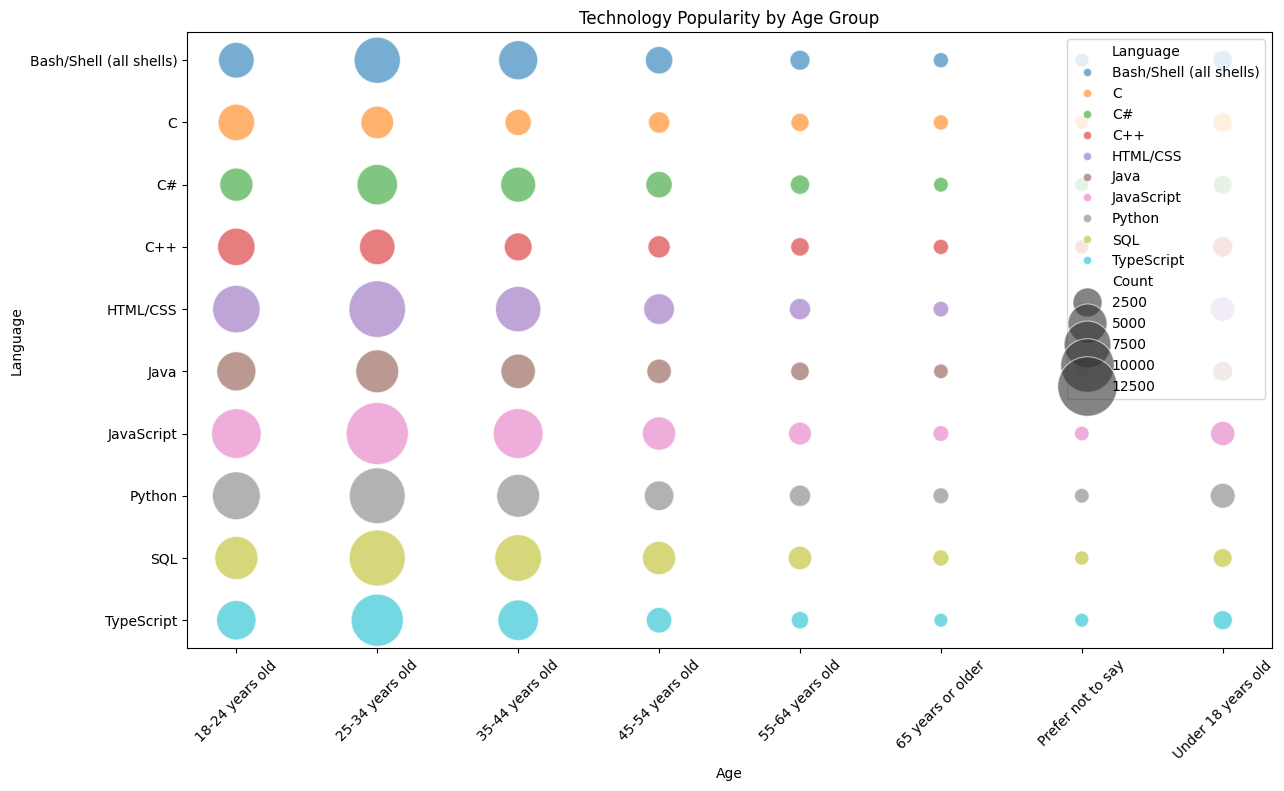

In [ ]:
df_lang = df[['LanguageHaveWorkedWith', 'Age']].dropna()
df_lang['Language'] = df_lang['LanguageHaveWorkedWith'].str.split(';')
df_exploded = df_lang.explode('Language')

# Wybieramy top 10 języków dla czytelności
top_10_langs = df_exploded['Language'].value_counts().nlargest(10).index
lang_age_count = df_exploded[df_exploded['Language'].isin(top_10_langs)].groupby(['Age', 'Language']).size().reset_index(name='Count')

plt.figure(figsize=(14, 8))
sns.scatterplot(data=lang_age_count, x='Age', y='Language', size='Count', hue='Language',
                sizes=(100, 2000), alpha=0.6)
plt.title('Technology Popularity by Age Group')
plt.xticks(rotation=45)
plt.show()

#### 2. Bubble Plot for Preferred Databases vs. Job Satisfaction

- Explore the relationship between preferred databases (`DatabaseWantToWorkWith`) and job satisfaction.

- Use bubble size to indicate the number of respondents for each database.


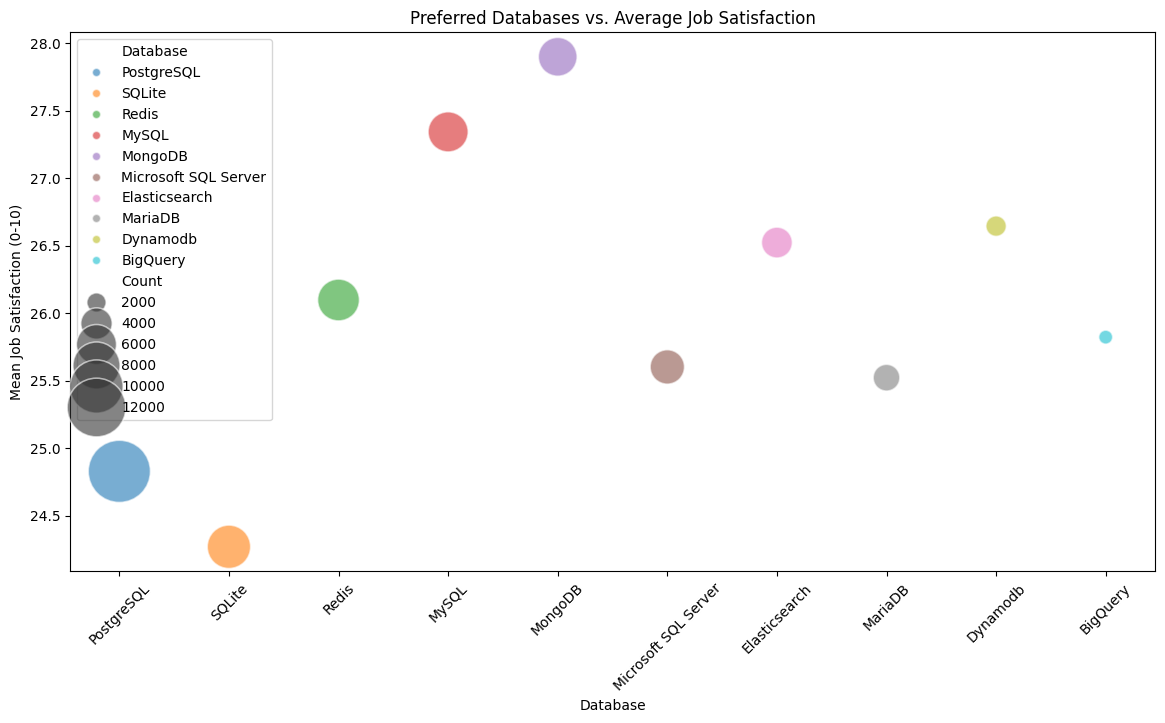

In [ ]:
# 1. Przygotowanie danych (explode dla DatabaseWantToWorkWith)
df_db = df[['DatabaseWantToWorkWith', 'JobSatPoints_6']].dropna()
df_db['Database'] = df_db['DatabaseWantToWorkWith'].str.split(';')
df_db_exploded = df_db.explode('Database')

# 2. Agregacja: średnia satysfakcja i liczba respondentów dla każdej bazy
db_summary = df_db_exploded.groupby('Database').agg(
    Avg_JobSat=('JobSatPoints_6', 'mean'),
    Count=('JobSatPoints_6', 'count')
).reset_index()

# 3. Wybieramy top 10 baz danych pod względem liczby chętnych
top_10_db = db_summary.nlargest(10, 'Count')

# 4. Bubble Plot
plt.figure(figsize=(14, 7))
sns.scatterplot(data=top_10_db, x='Database', y='Avg_JobSat', size='Count',
                hue='Database', sizes=(100, 2000), alpha=0.6)
plt.title('Preferred Databases vs. Average Job Satisfaction')
plt.ylabel('Mean Job Satisfaction (0-10)')
plt.xticks(rotation=45)
plt.show()

### Task 3: Comparing Data Using Bubble Plots


#### 1. Bubble Plot for Compensation Across Developer Roles

- Visualize compensation (`ConvertedCompYearly`) across different developer roles (`DevType`).

- Use bubble size to represent job satisfaction.


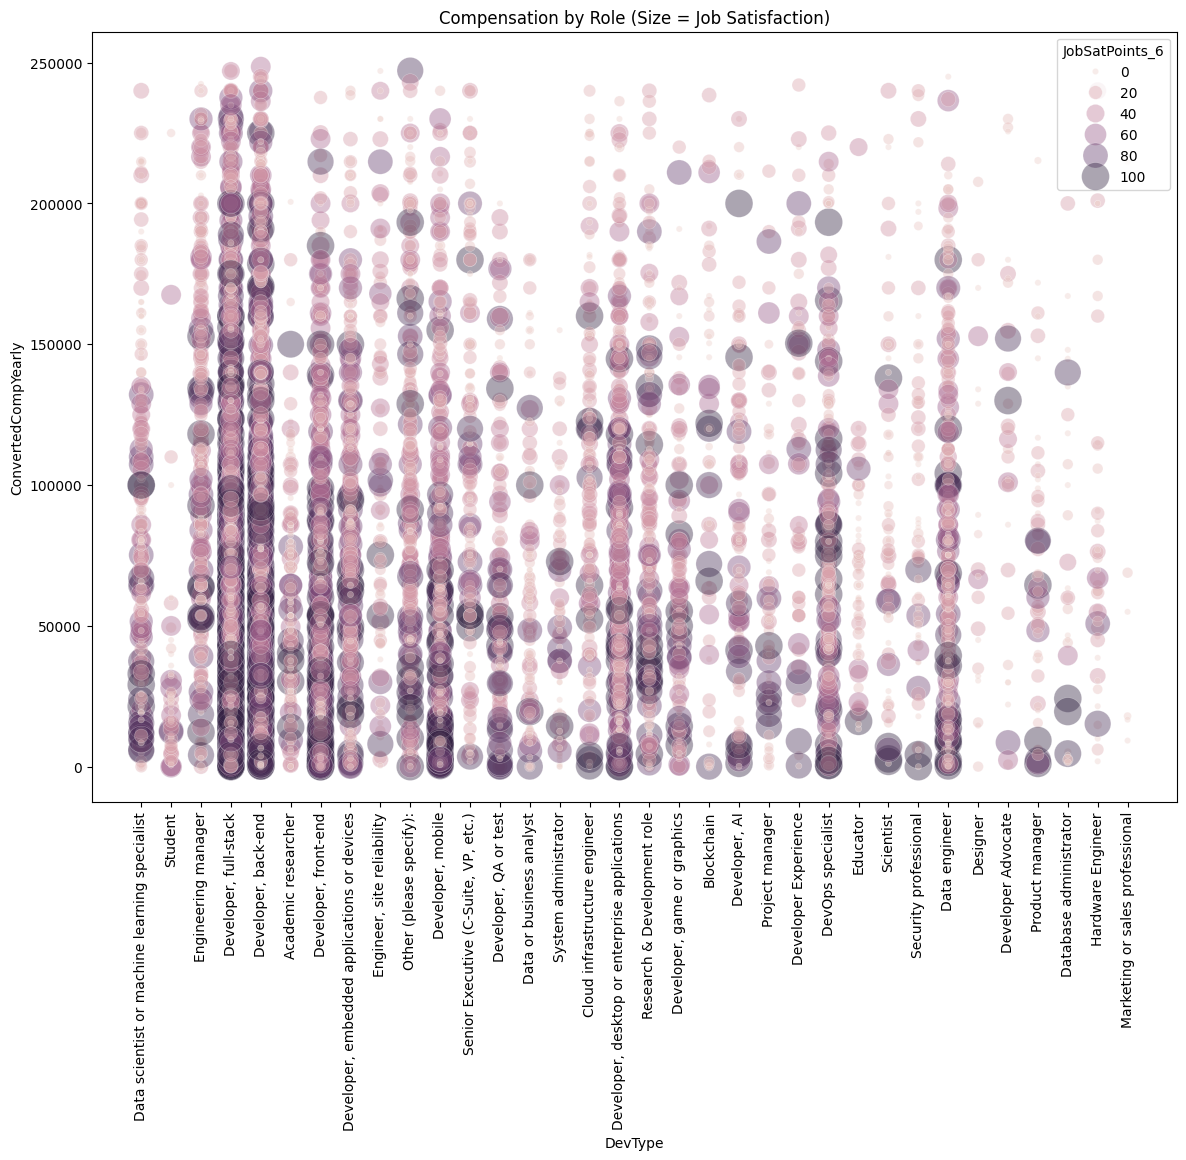

In [ ]:
df_roles = df[['DevType', 'ConvertedCompYearly', 'JobSatPoints_6']].dropna()
df_roles = df_roles[df_roles['ConvertedCompYearly'] < 250000] # usuwamy outliery

plt.figure(figsize=(14, 10))
sns.scatterplot(data=df_roles, x='DevType', y='ConvertedCompYearly', size='JobSatPoints_6',
                hue='JobSatPoints_6', alpha=0.4, sizes=(20, 400))
plt.title('Compensation by Role (Size = Job Satisfaction)')
plt.xticks(rotation=90)
plt.show()

#### 2. Bubble Plot for Collaboration Tools by Age

- Visualize the relationship between the collaboration tools used (`NEWCollabToolsHaveWorkedWith`) and age groups.

- Use bubble size to represent the frequency of tool usage.


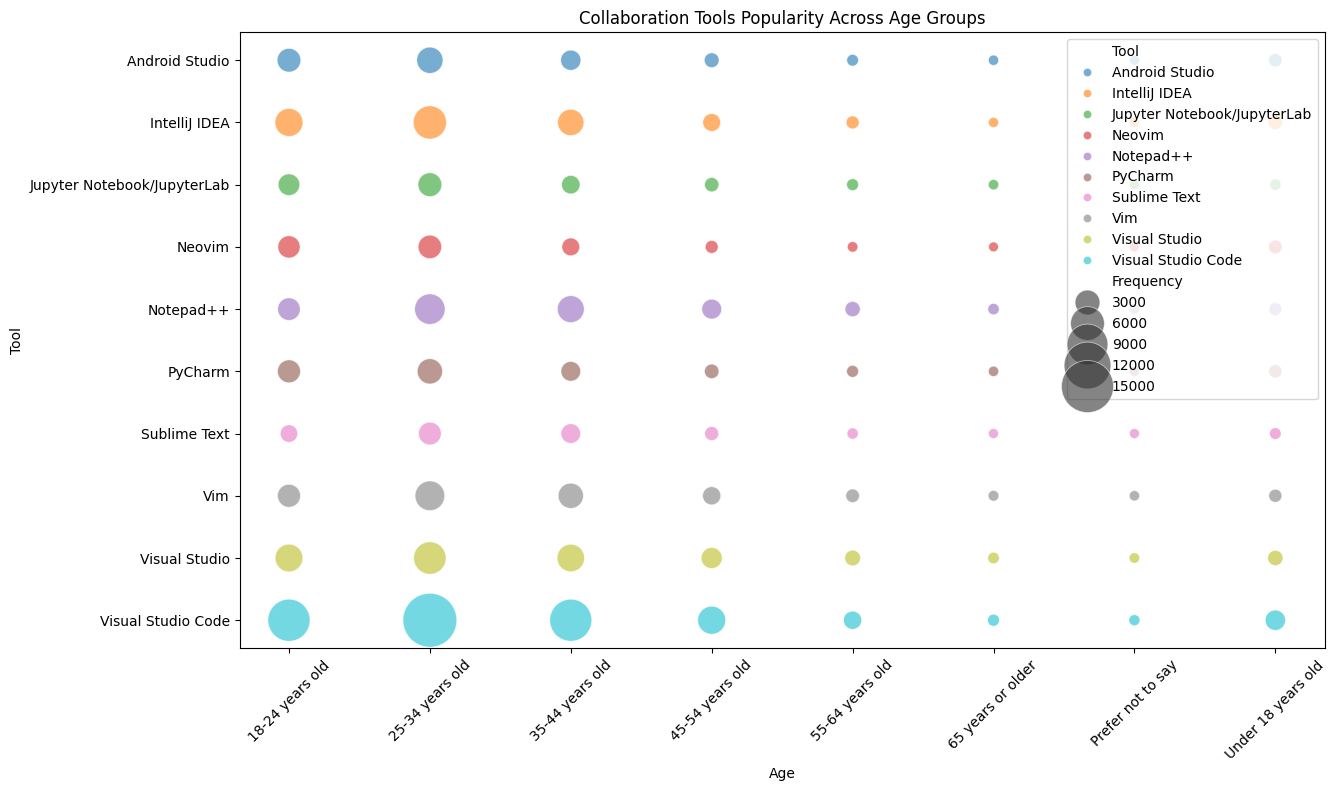

In [ ]:
# 1. Przygotowanie danych
df_tools = df[['NEWCollabToolsHaveWorkedWith', 'Age']].dropna()
df_tools['Tool'] = df_tools['NEWCollabToolsHaveWorkedWith'].str.split(';')
df_tools_exploded = df_tools.explode('Tool')

# 2. Liczenie częstotliwości występowania narzędzia w każdej grupie wiekowej
tools_age_summary = df_tools_exploded.groupby(['Age', 'Tool']).size().reset_index(name='Frequency')

# 3. Wybieramy 10 najpopularniejszych narzędzi ogółem
top_tools = df_tools_exploded['Tool'].value_counts().nlargest(10).index
plot_tools_data = tools_age_summary[tools_age_summary['Tool'].isin(top_tools)]

# 4. Bubble Plot
plt.figure(figsize=(14, 8))
sns.scatterplot(data=plot_tools_data, x='Age', y='Tool', size='Frequency',
                hue='Tool', sizes=(50, 1500), alpha=0.6)
plt.title('Collaboration Tools Popularity Across Age Groups')
plt.xticks(rotation=45)
plt.show()

### Task 4: Visualizing Technology Trends Using Bubble Plots


#### 1. Bubble Plot for Preferred Web Frameworks vs. Job Satisfaction

- Explore the relationship between preferred web frameworks (`WebframeWantToWorkWith`) and job satisfaction.

- Use bubble size to represent the number of respondents.



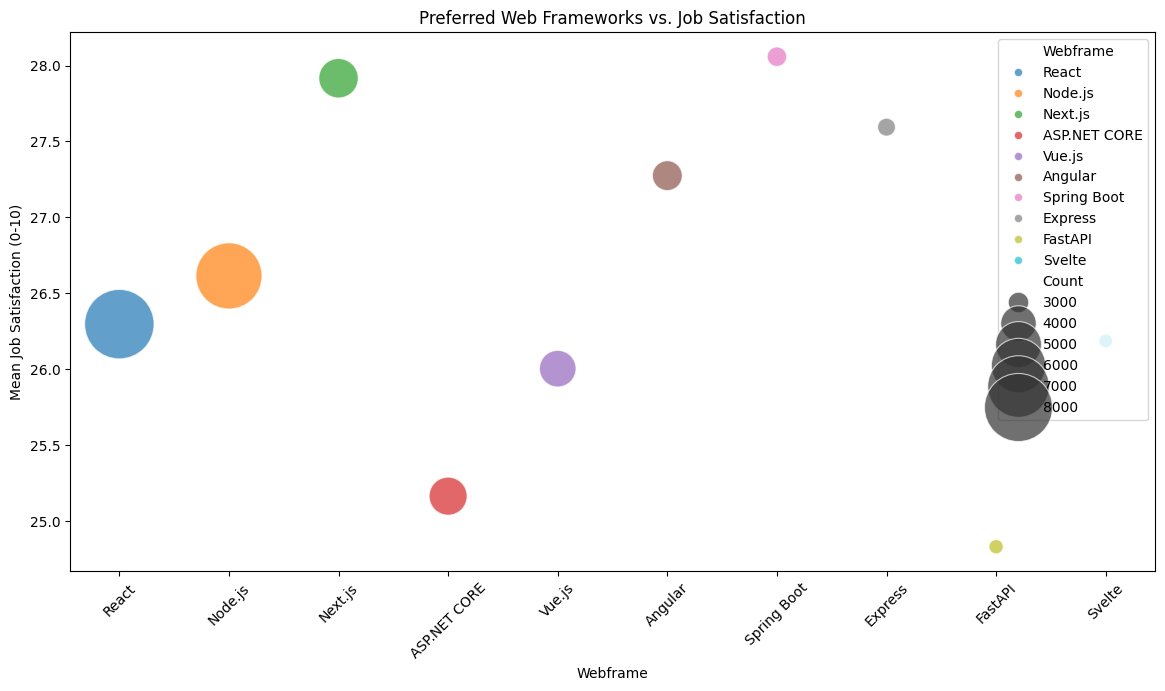

In [ ]:
# 1. Przygotowanie danych
df_web = df[['WebframeWantToWorkWith', 'JobSatPoints_6']].dropna()
df_web['Webframe'] = df_web['WebframeWantToWorkWith'].str.split(';')
df_web_exploded = df_web.explode('Webframe')

# 2. Agregacja danych
web_summary = df_web_exploded.groupby('Webframe').agg(
    Avg_JobSat=('JobSatPoints_6', 'mean'),
    Count=('JobSatPoints_6', 'count')
).reset_index()

# 3. Wybieramy top 10 frameworków
top_10_web = web_summary.nlargest(10, 'Count')

# 4. Bubble Plot
plt.figure(figsize=(14, 7))
sns.scatterplot(data=top_10_web, x='Webframe', y='Avg_JobSat', size='Count',
                hue='Webframe', sizes=(100, 2500), alpha=0.7)
plt.title('Preferred Web Frameworks vs. Job Satisfaction')
plt.ylabel('Mean Job Satisfaction (0-10)')
plt.xticks(rotation=45)
plt.show()

#### 2. Bubble Plot for Admired Technologies Across Countries

- Visualize the distribution of admired technologies (`LanguageAdmired`) across different countries (`Country`).

- Use bubble size to represent the frequency of admiration.



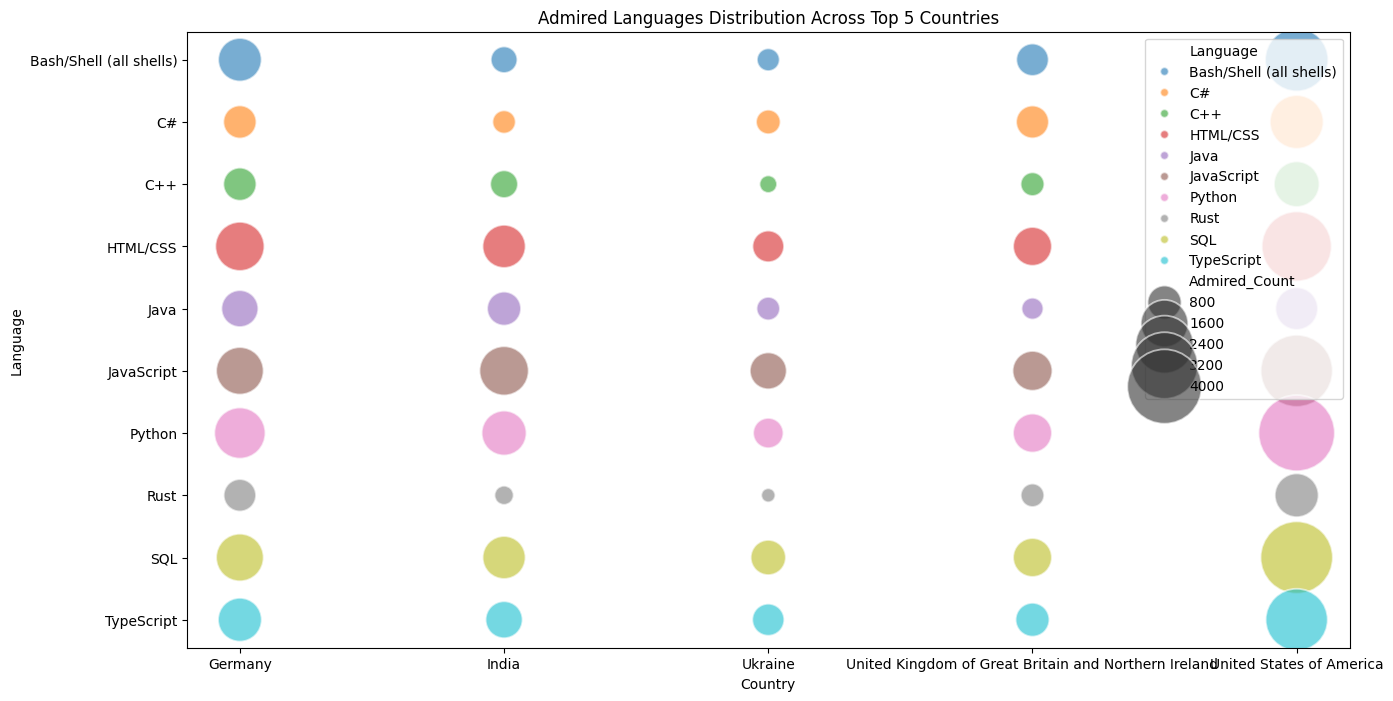

In [ ]:
# 1. Przygotowanie danych
df_admired = df[['LanguageAdmired', 'Country']].dropna()
df_admired['Language'] = df_admired['LanguageAdmired'].str.split(';')
df_admired_exploded = df_admired.explode('Language')

# 2. Wybieramy Top 5 krajów i Top 10 języków dla czytelności
top_5_countries = df['Country'].value_counts().nlargest(5).index
top_10_admired_langs = df_admired_exploded['Language'].value_counts().nlargest(10).index

# 3. Filtrowanie i liczenie częstotliwości
admired_summary = df_admired_exploded[
    (df_admired_exploded['Country'].isin(top_5_countries)) &
    (df_admired_exploded['Language'].isin(top_10_admired_langs))
].groupby(['Country', 'Language']).size().reset_index(name='Admired_Count')

# 4. Bubble Plot
plt.figure(figsize=(15, 8))
sns.scatterplot(data=admired_summary, x='Country', y='Language', size='Admired_Count',
                hue='Language', sizes=(100, 3000), alpha=0.6)
plt.title('Admired Languages Distribution Across Top 5 Countries')
plt.show()

## Final Step: Review


After completing the lab, you will have extensively used bubble plots to gain insights into developer community preferences, demographics, compensation trends, and job satisfaction.


## Summary


After completing this lab, you will be able to:

- Create and interpret bubble plots to analyze relationships and compositions within datasets.

- Use bubble plots to explore developer preferences, compensation trends, and satisfaction levels.

- Apply bubble plots to visualize complex relationships involving multiple dimensions effectively.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-10-29|1.2|Madhusudhan Moole|Updated lab|
|2024-10-16|1.1|Madhusudhan Moole|Updated lab|
|2024-10-15|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
